In [6]:
import pyarrow.parquet as pq
import polars as pl
import os

pl.Config.set_tbl_cols(30) 
pl.Config.set_tbl_rows(80)   
pl.Config.set_tbl_width_chars(500)  # Make the table wider in the console
pl.Config.set_fmt_str_lengths(50)   # Don't cut off long strings like stoch_key


# Define the file path
file_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260504_144302_01\trade_ml_partitioned'
file_path_sample = os.path.join(file_path, "era_int=20220901", "trade_ml_era_int=20220901.parquet")

# Check if file exists to avoid errors
if os.path.exists(file_path_sample):
    # Open the parquet file metadata
    parquet_file = pq.ParquetFile(file_path_sample)
    
    # 1. Get the Schema
    schema = parquet_file.schema.to_arrow_schema()
    
    # 2. Get Total Row Count
    total_rows = parquet_file.metadata.num_rows
    
    print(f"--- File Statistics ---")
    print(f"Total Rows: {total_rows:,}")
    print(f"\n--- PyArrow Schema ---")
    print(schema)
else:
    print(f"Error: File not found at {file_path_sample}")

--- File Statistics ---
Total Rows: 2,118

--- PyArrow Schema ---
regime_id: int32
signal_layer: int8
signal_scope_id: large_string
era_int: int64
side: int8
SL: float
TP: float
SL_hit: float
TP_hit: float
signal_idx: int64
signal_time_ns: int64
signal_price: float
order_idx: int64
order_time_ns: int64
order_price: float
order_mode: int8
fill_status: int8
entry_idx: int64
entry_time_ns: int64
entry_price: float
exit_idx: int64
exit_time_ns: int64
exit_price: float
exit_reason: int8
fill_delay_bars: int32
pnl_pct: float


In [7]:
import polars as pl
import os
from pathlib import Path

# --- CONFIG ---
# Note: Using the session from your previous error log
SESSION = "Opt_Session_20260504_144302_01" 
BASE_DIR = Path(r"C:\Users\Owner\airflow-trading\data_lake") / SESSION / "trade_ml_partitioned"

print(f"Checking directory: {BASE_DIR}")

if not BASE_DIR.exists():
    print("❌ Directory does not exist. Check your session name or path.")
else:
    # 1. Scan all parquet files in the folder (including subdirectories)
    # We use scan_parquet for speed
    lf = pl.scan_parquet(str(BASE_DIR / "**" / "*.parquet"))

    # 2. Get unique regime_ids and their trade counts
    regime_counts = (
        lf.group_by("regime_id")
        .agg(pl.count().alias("trade_count"))
        .sort("regime_id")
        .collect()
    )

    # 3. Print Results
    print("\n--- Summary of Regimes found in Trade ML Data ---")
    if regime_counts.is_empty():
        print("❌ No data found! (Check if the parquet files are empty)")
    else:
        print(regime_counts)
        
        # 4. Detailed Validation
        found_ids = regime_counts["regime_id"].to_list()
        total_trades = regime_counts["trade_count"].sum()
        
        print(f"\nTotal trades across all files: {total_trades:,}")
        print(f"Unique Regime IDs discovered: {found_ids}")
        
        # Check for nulls
        null_count = lf.select(pl.col("regime_id").is_null().sum()).collect().item()
        if null_count > 0:
            print(f"⚠️ Warning: Found {null_count} rows where regime_id is NULL")

    # 5. Quick look at the schema to confirm types
    print("\n--- Column Type Check ---")
    print(f"regime_id type: {lf.schema['regime_id']}")

Checking directory: C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260504_144302_01\trade_ml_partitioned

--- Summary of Regimes found in Trade ML Data ---
shape: (28, 2)
┌───────────┬─────────────┐
│ regime_id ┆ trade_count │
│ ---       ┆ ---         │
│ i32       ┆ u32         │
╞═══════════╪═════════════╡
│ 0         ┆ 717         │
│ 1         ┆ 852         │
│ 2         ┆ 705         │
│ 3         ┆ 853         │
│ 4         ┆ 701         │
│ 5         ┆ 818         │
│ 6         ┆ 709         │
│ 7         ┆ 849         │
│ 8         ┆ 691         │
│ 9         ┆ 816         │
│ 10        ┆ 708         │
│ 11        ┆ 849         │
│ 12        ┆ 637         │
│ 13        ┆ 733         │
│ 14        ┆ 1056        │
│ 15        ┆ 1112        │
│ 16        ┆ 1057        │
│ 17        ┆ 1111        │
│ 18        ┆ 1008        │
│ 19        ┆ 1062        │
│ 20        ┆ 1033        │
│ 21        ┆ 1102        │
│ 22        ┆ 1006        │
│ 23        ┆ 1049        │
│ 24     

C:\Users\Owner\AppData\Local\Temp\ipykernel_3936\3883085514.py:22: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("trade_count"))
C:\Users\Owner\AppData\Local\Temp\ipykernel_3936\3883085514.py:48: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(f"regime_id type: {lf.schema['regime_id']}")


Found 12 parquet files.
Success! Loaded 413 trades.
TOTAL LIMIT ORDER: 413
OPEN ORDER (no exit_idx): 0
CLOSED ORDER: 413
SUMMARY:
regime_id: 0
total_trades: 413
sl_loss_count: 18
sl_profit_exit_count: 0
tp_count: 68
time_exit_count: 327
sl_exit_count: 18
tp_exit_count: 68
sl_loss_share_of_sl_events_pct: 100.0
sl_profit_share_of_sl_events_pct: 0.0
positive_pnl_count: 227
positive_pnl_rate_pct: 54.9636803874092
avg_pnl_pct: 0.030774366110563278
median_pnl_pct: 0.06301384419202805

SL LOSS STATS (%): {'count': 18, 'mean_pct': 210.00997924804688, 'median_pct': 210.00997924804688, 'std_pct': 0.0, 'p90_pct': 210.00997924804688, 'p95_pct': 210.00997924804688, 'p99_pct': 210.00997924804688}
SL PROFIT EXIT STATS (%): {'count': 0, 'mean_pct': nan, 'median_pct': nan, 'std_pct': nan, 'p90_pct': nan, 'p95_pct': nan, 'p99_pct': nan}
TP STATS (%): {'count': 68, 'mean_pct': 100.0, 'median_pct': 100.0, 'std_pct': 0.0, 'p90_pct': 100.0, 'p95_pct': 100.0, 'p99_pct': 100.0}
PNL STATS (%): {'count': 413, '

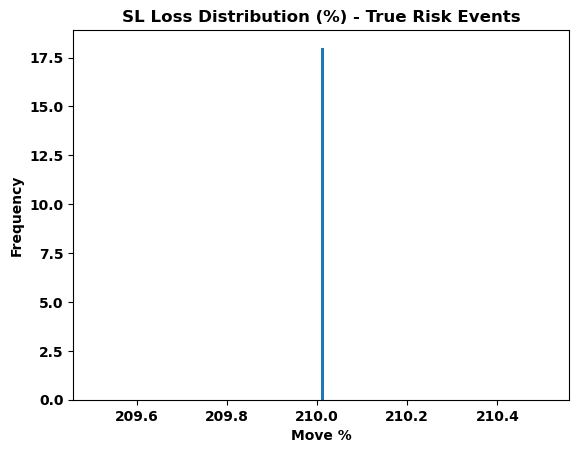

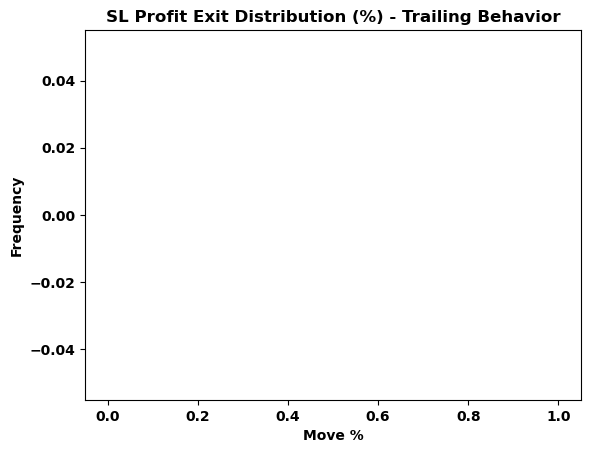

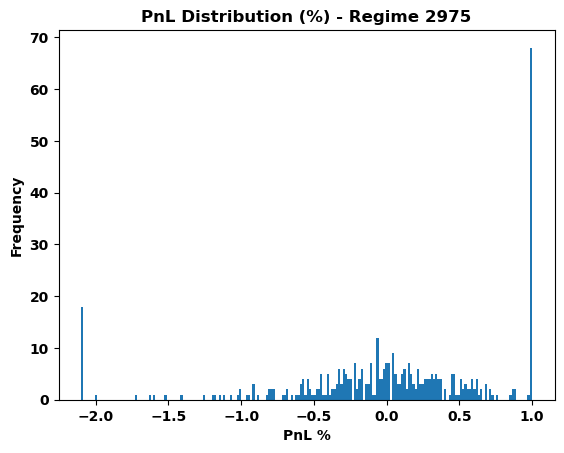

In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from post_grid_config import (
    REGIME_ID,
    TOP_N_ROWS_TO_PRINT,
    SESSION_NAME,
    trade_ml_analysis_root,
    trade_ml_partitioned_root,
)

pl.Config.set_tbl_cols(40)
pl.Config.set_tbl_rows(80)
pl.Config.set_tbl_width_chars(500)
pl.Config.set_fmt_str_lengths(80)


def load_trade_ml_result() -> pl.DataFrame:
    base_path = trade_ml_partitioned_root()
    files = sorted(base_path.rglob("*.parquet"))

    print(f"Session: {SESSION_NAME}")
    print(f"Base path: {base_path}")
    print(f"Found {len(files)} parquet files.")

    if len(files) == 0:
        if not base_path.exists():
            print(f"ERROR: The directory does not exist: {base_path}")
        else:
            print(f"Directory exists, but no parquets found in: {base_path}")
        raise FileNotFoundError("Glob found zero parquet files.")

    lf = pl.scan_parquet([str(p) for p in files])

    cols = [
        "regime_id", "signal_layer", "signal_scope_id",
        "era_int", "signal_idx", "entry_idx", "entry_time_ns",
        "exit_idx", "exit_time_ns", "exit_reason",
        "SL", "TP", "SL_hit", "TP_hit", "pnl_pct"
    ]

    if REGIME_ID is not None:
        lf = lf.filter(pl.col("regime_id") == int(REGIME_ID))

    result = lf.select(cols).collect(engine="streaming")

    if result.is_empty():
        print(f"WARNING: no rows found for regime_id={REGIME_ID}")
        check = (
            pl.scan_parquet([str(p) for p in files])
            .filter(pl.col("regime_id") == int(REGIME_ID))
            .select(["SL", "TP"])
            .unique()
            .collect(engine="streaming")
        )
        print(check)
    else:
        print(f"Success! Loaded {result.height} trades for regime_id={REGIME_ID}")

    return result

# --------------------------
# VERIFY HOW MANY TRADES ARE STILL OPEN
# --------------------------
open_trades = result.select(pl.col("exit_idx").is_null().sum()).item()
total_trades = result.height

print("TOTAL LIMIT ORDER:", total_trades)
print("OPEN ORDER (no exit_idx):", open_trades)
print("CLOSED ORDER:", total_trades - open_trades)
# Sort trades inside each era so compounding is reproducible.
sort_cols = [c for c in ["era_int", "entry_time_ns", "entry_idx", "signal_idx", "exit_idx"] if c in result.columns]
result = result.sort(sort_cols)

# Convert to numpy.
sl = result["SL_hit"].to_numpy()
tp = result["TP_hit"].to_numpy()
pnl = result["pnl_pct"].to_numpy()
exit_reason = result["exit_reason"].to_numpy()
era_int_arr = result["era_int"].to_numpy()

# --------------------------
# Split exit types correctly
# --------------------------
sl_loss = sl[np.isfinite(sl) & (sl > 0)]
sl_profit = sl[np.isfinite(sl) & (sl < 0)]
tp_valid = tp[np.isfinite(tp)]
pnl_valid = pnl[np.isfinite(pnl)]

# Percent-unit versions for display/plots.
sl_loss_pct = sl_loss * 100.0
sl_profit_pct = sl_profit * 100.0
tp_pct = tp_valid * 100.0
pnl_pct = pnl_valid * 100.0

# --------------------------
# Summary helpers
# --------------------------
def pct_stats(x: np.ndarray) -> dict[str, float]:
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {
            "count": 0,
            "mean_pct": np.nan,
            "median_pct": np.nan,
            "std_pct": np.nan,
            "p90_pct": np.nan,
            "p95_pct": np.nan,
            "p99_pct": np.nan,
        }
    return {
        "count": int(x.size),
        "mean_pct": float(np.mean(x)),
        "median_pct": float(np.median(x)),
        "std_pct": float(np.std(x)),
        "p90_pct": float(np.percentile(x, 90)),
        "p95_pct": float(np.percentile(x, 95)),
        "p99_pct": float(np.percentile(x, 99)),
    }

total_trades = int(result.height)
sl_loss_count = int(np.sum(np.isfinite(sl) & (sl > 0)))
sl_profit_count = int(np.sum(np.isfinite(sl) & (sl < 0)))
tp_count = int(np.sum(np.isfinite(tp)))
time_exit_count = int(np.sum(exit_reason == 0))
sl_exit_count = int(np.sum(exit_reason == -1))
tp_exit_count = int(np.sum(exit_reason == 1))

summary = {
    "regime_id": 0,
    "total_trades": total_trades,
    "sl_loss_count": sl_loss_count,
    "sl_profit_exit_count": sl_profit_count,
    "tp_count": tp_count,
    "time_exit_count": time_exit_count,
    "sl_exit_count": sl_exit_count,
    "tp_exit_count": tp_exit_count,
    "sl_loss_share_of_sl_events_pct": float(100.0 * sl_loss_count / max(sl_loss_count + sl_profit_count, 1)),
    "sl_profit_share_of_sl_events_pct": float(100.0 * sl_profit_count / max(sl_loss_count + sl_profit_count, 1)),
    "positive_pnl_count": int(np.sum(np.isfinite(pnl) & (pnl > 0))),
    "positive_pnl_rate_pct": float(100.0 * np.sum(np.isfinite(pnl) & (pnl > 0)) / max(np.sum(np.isfinite(pnl)), 1)),
    "avg_pnl_pct": float(np.mean(pnl_pct)) if pnl_pct.size else np.nan,
    "median_pnl_pct": float(np.median(pnl_pct)) if pnl_pct.size else np.nan,
}

print("SUMMARY:")
for k, v in summary.items():
    print(f"{k}: {v}")

print("\nSL LOSS STATS (%):", pct_stats(sl_loss_pct))
print("SL PROFIT EXIT STATS (%):", pct_stats(sl_profit_pct))
print("TP STATS (%):", pct_stats(tp_pct))
print("PNL STATS (%):", pct_stats(pnl_pct))

# --------------------------
# Per-era reset-balance check
# --------------------------
# Balance resets to 100 at the start of every era.
# We compound pnl_pct inside each era in trade order.
era_rows = []

grouped = (
    result.group_by("era_int", maintain_order=True)
    .agg([
        pl.col("pnl_pct").alias("pnl_seq"),
        pl.col("SL_hit").alias("sl_seq"),
        pl.col("TP_hit").alias("tp_seq"),
        pl.col("exit_reason").alias("exit_seq"),
        pl.len().alias("trades"),
    ])
)

for row in grouped.iter_rows(named=True):
    era = int(row["era_int"])

    pnl_seq = np.asarray(row["pnl_seq"], dtype=np.float64)
    pnl_seq = pnl_seq[np.isfinite(pnl_seq)]
    pnl_seq = np.clip(pnl_seq, -0.999999, None)

    sl_seq = np.asarray(row["sl_seq"], dtype=np.float64)
    sl_seq = sl_seq[np.isfinite(sl_seq)]

    tp_seq = np.asarray(row["tp_seq"], dtype=np.float64)
    tp_seq = tp_seq[np.isfinite(tp_seq)]

    exit_seq = np.asarray(row["exit_seq"], dtype=np.int64)

    if pnl_seq.size:
        equity = 100.0 * np.cumprod(1.0 + pnl_seq)
        end_balance = float(equity[-1])
        peak_balance = float(np.max(equity))
        trough_balance = float(np.min(equity))
    else:
        equity = np.array([], dtype=np.float64)
        end_balance = 100.0
        peak_balance = 100.0
        trough_balance = 100.0

    end_return_pct = (end_balance / 100.0 - 1.0) * 100.0
    peak_return_pct = (peak_balance / 100.0 - 1.0) * 100.0
    trough_return_pct = (trough_balance / 100.0 - 1.0) * 100.0

    era_rows.append({
        "era_int": era,
        "trades": int(row["trades"]),
        "end_balance": end_balance,
        "end_return_pct": end_return_pct,
        "peak_balance": peak_balance,
        "peak_return_pct": peak_return_pct,
        "trough_balance": trough_balance,
        "trough_return_pct": trough_return_pct,
        "hit_5pct_end": bool(end_return_pct >= 5.0),
        "hit_5pct_peak": bool(peak_return_pct >= 5.0),
        "sl_loss_count": int(np.sum(sl_seq > 0)),
        "sl_profit_exit_count": int(np.sum(sl_seq < 0)),
        "tp_count": int(tp_seq.size),
        "tp_exit_count": int(np.sum(exit_seq == 1)),
        "sl_exit_count": int(np.sum(exit_seq == -1)),
        "time_exit_count": int(np.sum(exit_seq == 0)),
        "avg_pnl_pct": float(np.mean(pnl_seq) * 100.0) if pnl_seq.size else np.nan,
        "median_pnl_pct": float(np.median(pnl_seq) * 100.0) if pnl_seq.size else np.nan,
    })

era_table = pl.DataFrame(era_rows).sort(["era_int"])

print("\nPER-ERA RESET BALANCE TABLE:")
print(era_table)

print("\nERAS ENDING ABOVE +5%:")
print(
    era_table.select([
        pl.len().alias("eras_total"),
        pl.col("hit_5pct_end").sum().alias("eras_above_5pct_at_end"),
        pl.col("hit_5pct_peak").sum().alias("eras_above_5pct_at_peak"),
        (pl.col("hit_5pct_end").mean() * 100).alias("end_hit_rate_pct"),
        (pl.col("hit_5pct_peak").mean() * 100).alias("peak_hit_rate_pct"),
    ])
)

# --------------------------
# Visuals
# --------------------------
plt.figure()
plt.hist(sl_loss_pct, bins=200)
plt.title("SL Loss Distribution (%) - True Risk Events")
plt.xlabel("Move %")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(sl_profit_pct, bins=200)
plt.title("SL Profit Exit Distribution (%) - Trailing Behavior")
plt.xlabel("Move %")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(pnl_pct, bins=200)
plt.title("PnL Distribution (%) - Regime 2975")
plt.xlabel("PnL %")
plt.ylabel("Frequency")
plt.show()

In [8]:
from __future__ import annotations

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

file_path = r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260417_080040_01\trade_ml_partitioned\**\*.parquet"

lf = pl.scan_parquet(file_path)

df = (
    lf.filter(pl.col("regime_id") == 2975)
    .select([
        "regime_id",
        "era_int",
        "signal_idx",
        "fill_status",
        "entry_idx",
        "exit_idx",
        "exit_reason",
        "SL_hit",
        "TP_hit",
        "pnl_pct",
    ])
)

result = df.collect(streaming=True)

print("TOTAL ROWS:", result.height)
print("FILLED TRADES:", int((result["fill_status"] == 1).sum()))
print("UNFILLED SIGNAL ROWS:", int((result["fill_status"] == 0).sum()))
print("EXIT_IDX < 0:", int((result["exit_idx"] < 0).sum()))

print("\nEXIT_REASON COUNTS:")
print(
    result.group_by("exit_reason")
    .len()
    .sort("exit_reason")
)

filled = result.filter(pl.col("fill_status") == 1)
unfilled = result.filter(pl.col("fill_status") == 0)

print("\nFILLED ONLY SUMMARY:")
print(
    filled.select([
        pl.len().alias("rows"),
        (pl.col("exit_reason") == -1).sum().alias("sl_count"),
        (pl.col("exit_reason") == 1).sum().alias("tp_count"),
        (pl.col("exit_reason") == 0).sum().alias("time_exit_count"),
        pl.col("pnl_pct").mean().alias("avg_pnl"),
        pl.col("pnl_pct").median().alias("median_pnl"),
    ])
)

print("\nUNFILLED SIGNAL SAMPLE:")
print(
    unfilled.select([
        "era_int",
        "signal_idx",
        "fill_status",
        "entry_idx",
        "exit_idx",
        "exit_reason",
        "pnl_pct",
    ]).head(20)
)

print("\nFIRST FEW FILLED TRADES:")
print(
    filled.select([
        "era_int",
        "signal_idx",
        "entry_idx",
        "exit_idx",
        "exit_reason",
        "SL_hit",
        "TP_hit",
        "pnl_pct",
    ]).head(20)
)

C:\Users\Owner\AppData\Local\Temp\ipykernel_4988\1471006031.py:27: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  result = df.collect(streaming=True)


TOTAL ROWS: 167543
FILLED TRADES: 1258
UNFILLED SIGNAL ROWS: 166285
EXIT_IDX < 0: 166285

EXIT_REASON COUNTS:
shape: (3, 2)
┌─────────────┬────────┐
│ exit_reason ┆ len    │
│ ---         ┆ ---    │
│ i8          ┆ u32    │
╞═════════════╪════════╡
│ -2          ┆ 166285 │
│ -1          ┆ 1249   │
│ 1           ┆ 9      │
└─────────────┴────────┘

FILLED ONLY SUMMARY:
shape: (1, 6)
┌──────┬──────────┬──────────┬─────────────────┬─────────┬────────────┐
│ rows ┆ sl_count ┆ tp_count ┆ time_exit_count ┆ avg_pnl ┆ median_pnl │
│ ---  ┆ ---      ┆ ---      ┆ ---             ┆ ---     ┆ ---        │
│ u32  ┆ u32      ┆ u32      ┆ u32             ┆ f32     ┆ f32        │
╞══════╪══════════╪══════════╪═════════════════╪═════════╪════════════╡
│ 1258 ┆ 1249     ┆ 9        ┆ 0               ┆ 0.00102 ┆ -0.0004    │
└──────┴──────────┴──────────┴─────────────────┴─────────┴────────────┘

UNFILLED SIGNAL SAMPLE:
shape: (20, 7)
┌──────────┬────────────┬─────────────┬───────────┬──────────┬─────────

In [ ]:
print(np.isnan(result["exit_idx"]).sum())from __future__ import annotations

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

file_path = r"C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260417_080040_01\trade_ml_partitioned\**\*.parquet"

lf = pl.scan_parquet(file_path)

df = (
    lf.filter(pl.col("regime_id") == 2975)
    .select([
        "regime_id",
        "era_int",
        "signal_idx",
        "fill_status",
        "entry_idx",
        "exit_idx",
        "exit_reason",
        "SL_hit",
        "TP_hit",
        "pnl_pct",
    ])
)

result = df.collect(streaming=True)

print("TOTAL ROWS:", result.height)
print("FILLED TRADES:", int((result["fill_status"] == 1).sum()))
print("UNFILLED SIGNAL ROWS:", int((result["fill_status"] == 0).sum()))
print("EXIT_IDX < 0:", int((result["exit_idx"] < 0).sum()))

print("\nEXIT_REASON COUNTS:")
print(
    result.group_by("exit_reason")
    .len()
    .sort("exit_reason")
)

filled = result.filter(pl.col("fill_status") == 1)
unfilled = result.filter(pl.col("fill_status") == 0)

print("\nFILLED ONLY SUMMARY:")
print(
    filled.select([
        pl.len().alias("rows"),
        (pl.col("exit_reason") == -1).sum().alias("sl_count"),
        (pl.col("exit_reason") == 1).sum().alias("tp_count"),
        (pl.col("exit_reason") == 0).sum().alias("time_exit_count"),
        pl.col("pnl_pct").mean().alias("avg_pnl"),
        pl.col("pnl_pct").median().alias("median_pnl"),
    ])
)

print("\nUNFILLED SIGNAL SAMPLE:")
print(
    unfilled.select([
        "era_int",
        "signal_idx",
        "fill_status",
        "entry_idx",
        "exit_idx",
        "exit_reason",
        "pnl_pct",
    ]).head(20)
)

print("\nFIRST FEW FILLED TRADES:")
print(
    filled.select([
        "era_int",
        "signal_idx",
        "entry_idx",
        "exit_idx",
        "exit_reason",
        "SL_hit",
        "TP_hit",
        "pnl_pct",
    ]).head(20)
)

TypeError: No loop matching the specified signature and casting was found for ufunc isnan